# Deconvoluting NPQ induction curves with the Yggdrasill pipeline (PCA → full-harmonic phasor analysis → ALS-NMF)

Reproduction of: Ramakers L.A.I., Harbinson J., Wientjes E., van Amerongen H. (2024)
**"Unravelling the different components of nonphotochemical quenching using a novel analytical pipeline."**
*New Phytologist* 245(2):625–636, doi:[10.1111/nph.20271](https://doi.org/10.1111/nph.20271) (CC BY 4.0).

**Scope (partial demonstration).** We apply the paper's multivariate pipeline — mean-centred PCA,
PCA-guided full-harmonic phasor analysis (FH-PhA), geometric identification of the component
vertices, and non-negative matrix factorisation (adapted alternating least squares) — to the
authors' **wild-type Arabidopsis NPQ induction dataset (85 curves)** and then re-run it on the
**npq1 dataset (37 curves)**. We report component induction curves, fractional contributions vs
(1-qP)ss, and fit quality (adjusted r²). Chemical-treatment assignment and the low-resolution
pulse-sequence comparison are out of scope.

**AI-assisted reimplementation notice (English):** The authors distributed their pipeline only as a
Windows executable (`Yggdrasill_App.exe`, a Git LFS binary in commit `89851eca` of
[L-Ramakers/Yggdrasill](https://github.com/L-Ramakers/Yggdrasill)); **no source code is published**.
This notebook is an AI-assisted Python reimplementation written from the paper's Notes S1
(equations 1–5) and the adapted-ALS description (Berry et al. 2007). The executed example and its
checks were validated, but untested behaviour is not guaranteed. This is not author-provided code.

**AI支援による再実装に関する注意（日本語）：** 著者らの解析パイプラインはWindows用実行ファイルのみで
公開されており、ソースコードはありません。本ノートブックは論文 Notes S1 の式と Berry et al. (2007) の
ALSアルゴリズムに基づくAI支援によるPython再実装です。検証済みの実行例以外の動作は保証されません。

**Runtime:** CPU only (small matrix operations, seconds of compute). No GPU is used anywhere in the
method — select **CPU** runtime. Total downloads ≈ 3.3 MB; expected end-to-end ≈ 1–2 minutes.

## 1. Environment check

**EN:** Print the Python and library versions actually used. The pipeline needs only
`numpy`, `pandas`, `openpyxl` (Excel reader) and `matplotlib` — all preinstalled or trivially
installable on Colab.
**JP:** 使用するPythonとライブラリのバージョンを確認します。必要なのは numpy / pandas / openpyxl /
matplotlib のみです。

In [ ]:
import sys, numpy as np, pandas as pd, matplotlib
print('python', sys.version.split()[0])
print('numpy', np.__version__, '| pandas', pd.__version__, '| matplotlib', matplotlib.__version__)
try:
    import openpyxl; print('openpyxl', openpyxl.__version__)
except ImportError:
    import subprocess; subprocess.run([sys.executable,'-m','pip','install','-q','openpyxl'])
    import openpyxl; print('openpyxl (installed)', openpyxl.__version__)

python 3.13.15
numpy 2.1.3 | pandas 2.2.3 | matplotlib 3.10.0
openpyxl 3.1.5


## 2. Data acquisition (pinned author dataset)

**EN:** Download the authors' dataset zip from the pinned commit `89851eca` of
L-Ramakers/Yggdrasill (the exact repository named in the paper's Data availability statement).
The archive is 3,296,627 bytes and contains raw WinControl CSVs plus
`NPQ_induction_dataset_A_thaliana.xlsx`, the authors' assembled NPQ induction dataset.
**JP:** 論文指定のコミット `89851eca` からデータセット zip（約3.3 MB）をダウンロードします。
生のWinControl CSVと、著者らが整理済みの `NPQ_induction_dataset_A_thaliana.xlsx` が含まれます。

In [ ]:
import urllib.request, io, zipfile
URL = ('https://github.com/L-Ramakers/Yggdrasill/raw/'
       '89851ecab0ef8b25101da248c5ddfc14849ef7d4/'
       'wt%20and%20npq1%20Arabidopsis%20NPQ%20Datasets.zip')
data = urllib.request.urlopen(URL, timeout=180).read()
print('downloaded bytes:', len(data))
assert len(data) == 3296627, 'unexpected archive size'
z = zipfile.ZipFile(io.BytesIO(data))
XLSX = 'wt and npq1 Arabidopsis NPQ Datasets/wt and npq1 dataset (high temporal resolution)/NPQ_induction_dataset_A_thaliana.xlsx'
assert XLSX in z.namelist()
print('dataset xlsx found in archive')

downloaded bytes: 3296627
dataset xlsx found in archive


## 3. Load the assembled NPQ induction datasets

**EN:** The Excel file has one sheet per genotype. In each sheet, row 0 holds the steady-state
fraction of closed PSII reaction centres, (1-qP)ss, for every curve; column 0 holds the time axis
(minutes of illumination); remaining cells are NPQ values. We build `Y` (curves × time points),
`t_min` and `qp1` arrays for wt and npq1.
**JP:** 各シートの0行目は各曲線の (1-qP)ss、0列目は照射時間（分）、それ以外がNPQ値です。
wt（85曲線）と npq1（37曲線）の行列を読み込みます。

In [ ]:
import pandas as pd, numpy as np
xl = pd.ExcelFile(io.BytesIO(z.read(XLSX)))
print('sheets:', xl.sheet_names)

def load_sheet(name):
    df = xl.parse(name, header=None)
    qp1  = df.iloc[0, 1:].to_numpy(float)          # (1-qP)ss per curve
    tmin = df.iloc[1:, 0].to_numpy(float)          # time axis (minutes)
    Y    = df.iloc[1:, 1:].to_numpy(float).T       # (n_curves, n_timepoints) NPQ
    return Y, tmin, qp1

Y_wt, t_min, qp1_wt = load_sheet('wt')
Y_npq1, _, qp1_npq1 = load_sheet('npq1')
print('wt  :', Y_wt.shape, ' npq1:', Y_npq1.shape)
print('time range: %.2f – %.2f min, %d points' % (t_min[0], t_min[-1], len(t_min)))
print('(1-qP)ss range wt: %.3f – %.3f | npq1: %.3f – %.3f'
      % (qp1_wt.min(), qp1_wt.max(), qp1_npq1.min(), qp1_npq1.max()))
t_s = t_min * 60.0                                # seconds, used for the phasor integrals

sheets: ['wt', 'npq1']
wt  : (85, 26)  npq1: (37, 26)
time range: 0.16 – 9.64 min, 26 points
(1-qP)ss range wt: 0.011 – 0.819 | npq1: 0.180 – 0.859


## 4. Input preview — NPQ induction curves

**EN:** Plot the wt NPQ induction curves (NPQ = (Fm − Fm′)/Fm′, Stern–Volmer) against illumination
time, coloured by (1-qP)ss. At low light the curves show the characteristic transient maximum and
local minimum; at high light they rise monotonically — the line-shape changes the pipeline aims to
deconvolute (paper Fig. 1). This graph is generated here from the actual dataset.
**JP:** wtのNPQ誘導曲線を (1-qP)ss で色分けして表示します。低光では一時的な極大と極小、
高光では単調増加という、パイプラインが分離対象とする波形変化が見えます。

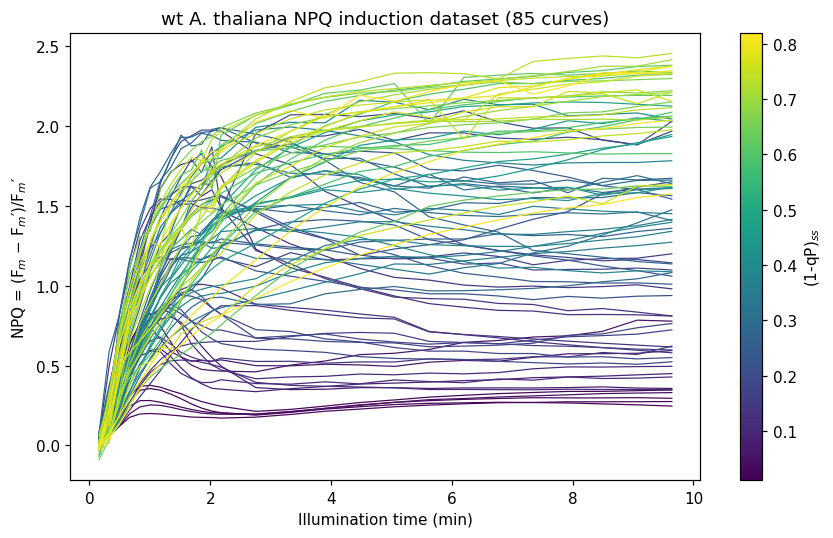

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 5), dpi=110)
sc = ax.scatter([], [])
order = np.argsort(qp1_wt)
cmap = plt.get_cmap('viridis')
for i in order:
    ax.plot(t_min, Y_wt[i], lw=0.8, color=cmap((qp1_wt[i]-qp1_wt.min())/(qp1_wt.max()-qp1_wt.min())))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(qp1_wt.min(), qp1_wt.max()))
fig.colorbar(sm, ax=ax, label='(1-qP)$_{ss}$')
ax.set_xlabel('Illumination time (min)'); ax.set_ylabel('NPQ = (F$_m$ − F$_m$′)/F$_m$′')
ax.set_title('wt A. thaliana NPQ induction dataset (85 curves)')
plt.tight_layout(); plt.show()

## 5. Stage 1 — mean-centred PCA

**EN:** The paper mean-centres the 85 curves and runs PCA (Notes S1 / Results). PC1 and PC2 should
explain ≈ 79.8 % and ≈ 16.1 % of the total variance (paper Fig. 2d). We use SVD directly so the
sign conventions are deterministic.
**JP:** 85本の曲線を平均中心化してPCAを実行します。PC1/PC2の寄与率は論文では約79.8 %/16.1 %です。

In [ ]:
def pca_curves(Y):
    X = Y - Y.mean(axis=0, keepdims=True)          # mean-centre across curves
    U, S, Vt = np.linalg.svd(X, full_matrices=False)
    var = S**2 / (S**2).sum()
    scores = U[:, :2] * S[:2]                      # (n_curves, 2)
    comps  = Vt[:2]                                # (2, n_timepoints)
    mean   = Y.mean(axis=0)
    return mean, comps, scores, var

mean_wt, comps_wt, scores_wt, var_wt = pca_curves(Y_wt)
print('explained variance: PC1 %.1f%%  PC2 %.1f%%  (paper: 79.8%% / 16.1%%)'
      % (100*var_wt[0], 100*var_wt[1]))
print('scree elbow at n=%d components' % (int(np.argmax(np.diff(np.cumsum(var_wt)) < 0.01)) + 2))

explained variance: PC1 87.4%  PC2 11.1%  (paper: 79.8% / 16.1%)
scree elbow at n=3 components


**EN:** Visualise the two principal components (line shapes) and their coefficients against
(1-qP)ss — the paper's Fig. 2a–c. PC1 rises monotonically (high-light-like); PC2 peaks near 2 min
(transient-like). This figure is generated from the actual data.
**JP:** 主成分の波形と、その係数の (1-qP)ss 依存性をプロットします（論文 Fig. 2a–c に対応）。

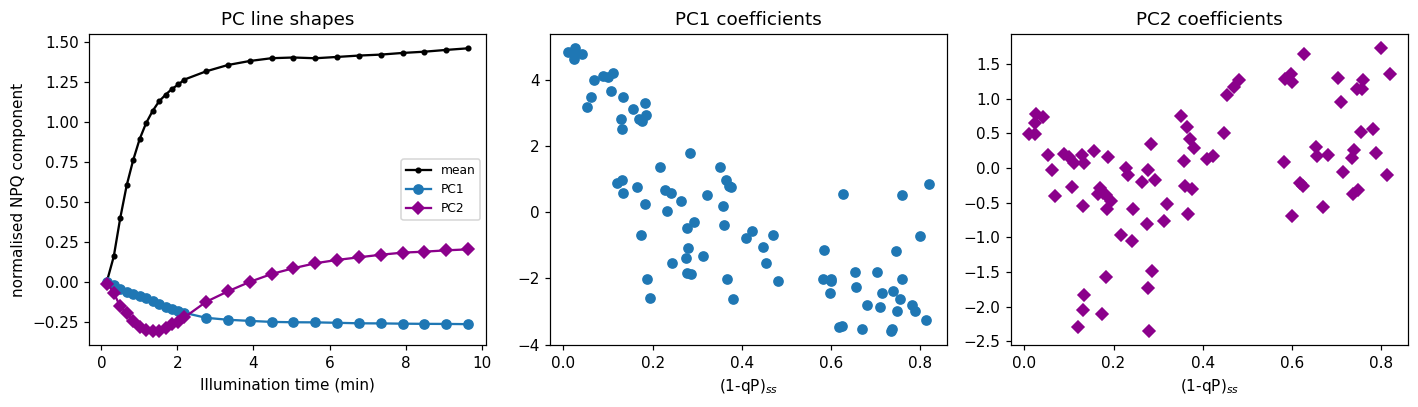

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), dpi=110)
axes[0].plot(t_min, mean_wt, 'k.-', label='mean')
axes[0].plot(t_min, comps_wt[0], 'o-', color='tab:blue', label='PC1')
axes[0].plot(t_min, comps_wt[1], 'D-', color='darkmagenta', label='PC2')
axes[0].set_xlabel('Illumination time (min)'); axes[0].set_ylabel('normalised NPQ component')
axes[0].legend(fontsize=8); axes[0].set_title('PC line shapes')
axes[1].plot(qp1_wt, scores_wt[:, 0], 'o', color='tab:blue')
axes[1].set_xlabel('(1-qP)$_{ss}$'); axes[1].set_title('PC1 coefficients')
axes[2].plot(qp1_wt, scores_wt[:, 1], 'D', color='darkmagenta')
axes[2].set_xlabel('(1-qP)$_{ss}$'); axes[2].set_title('PC2 coefficients')
plt.tight_layout(); plt.show()

## 6. Stage 2 — PCA-guided full-harmonic phasor analysis (FH-PhA)

**EN:** Following Notes S1.1: with total illumination time T = 600 s and a largest sampling step of
30 s, the allowed harmonics are ωₙ = 2πn/T up to the Nyquist limit (n ≤ 10). For every curve,
Gₙ = ∫NPQ·cos(ωₙt)dt / ∫NPQ·dt and Sₙ = ∫NPQ·sin(ωₙt)dt / ∫NPQ·dt (equations 1–3), evaluated by
trapezoidal integration on the measured time grid. PCA on the stacked (G, S) coordinates then maps
each curve into the full-harmonic phasor plane (G′ = PC1, S′ = PC2, equations 4–5).
**JP:** Notes S1.1 に従い、T=600 s、最大時間刻み30 s から ωₙ=2πn/T（n ≤ 10）の調波について
Gₙ・Sₙ を台形積分で計算し、その座標にPCAを適用してフルハーモニック位相空間へ射影します。

In [ ]:
T_TOTAL = t_s[-1] - t_s[0]
dt_max = np.diff(t_s).max()
n_max = int(np.floor(T_TOTAL / (2 * dt_max)))     # Nyquist limit on the 30 s grid
omegas = 2 * np.pi * np.arange(1, n_max + 1) / T_TOTAL
print('T = %.0f s, max step = %.0f s -> harmonics n = 1..%d' % (T_TOTAL, dt_max, n_max))

def phasor_coords(Y, t):
    G = np.array([np.trapezoid(Y*np.cos(w*t), t, axis=-1) / np.trapezoid(Y, t, axis=-1) for w in omegas])
    S = np.array([np.trapezoid(Y*np.sin(w*t), t, axis=-1) / np.trapezoid(Y, t, axis=-1) for w in omegas])
    return np.concatenate([G, S], axis=0).T        # (n_curves, 2*n_harmonics)

P_wt   = phasor_coords(Y_wt, t_s)
_, comps_pha, scores_pha, _ = pca_curves(P_wt)     # PCA of the phasor coordinates
Gprime_wt, Sprime_wt = scores_pha[:, 0], scores_pha[:, 1]
print('phasor coordinate matrix:', P_wt.shape)

T = 569 s, max step = 34 s -> harmonics n = 1..8
phasor coordinate matrix: (85, 16)


**EN:** Plot the wt dataset's trajectory through the full-harmonic phasor space, coloured by
(1-qP)ss (paper Fig. 3a). The trajectory is sigmoidal in (1-qP)ss — the coordinate the geometric
component identification uses. Generated from the actual data.
**JP:** データセットのフルハーモニック位相空間上の軌跡を (1-qP)ss で色分けして表示します
（論文 Fig. 3a に対応）。

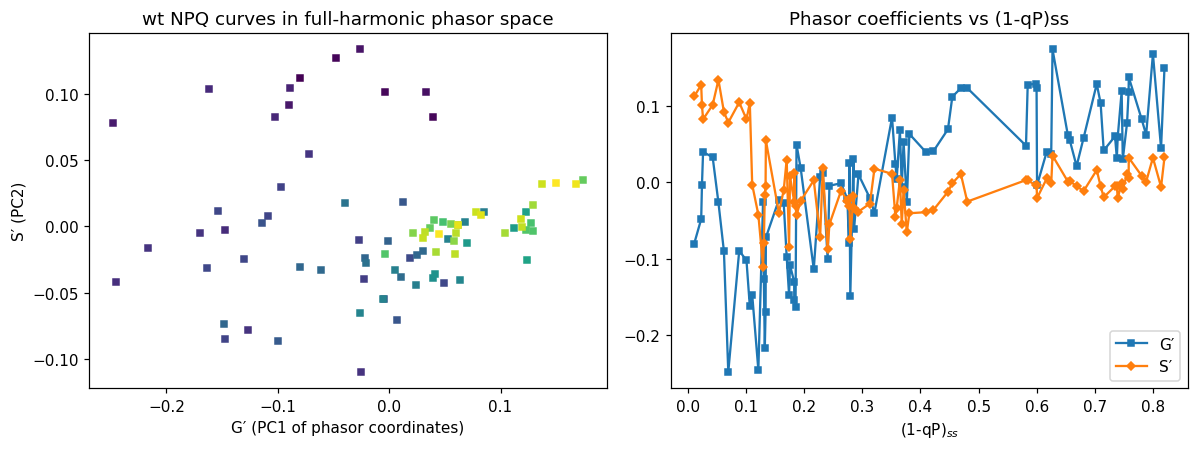

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), dpi=110)
o = np.argsort(qp1_wt)
for i in o:
    axes[0].plot(Gprime_wt[i], Sprime_wt[i], 's', ms=4,
                 color=cmap((qp1_wt[i]-qp1_wt.min())/(qp1_wt.max()-qp1_wt.min())))
axes[0].set_xlabel("G′ (PC1 of phasor coordinates)"); axes[0].set_ylabel("S′ (PC2)")
axes[0].set_title('wt NPQ curves in full-harmonic phasor space')
axes[1].plot(qp1_wt, Gprime_wt, 's-', ms=4, label="G′")
axes[1].plot(qp1_wt, Sprime_wt, 'D-', ms=4, label="S′")
axes[1].set_xlabel('(1-qP)$_{ss}$'); axes[1].legend(); axes[1].set_title('Phasor coefficients vs (1-qP)ss')
plt.tight_layout(); plt.show()

## 7. Geometric identification of the component vertices

**EN:** In phasor space a mixture of components lies on the segment/inside the triangle spanned by
the pure components (equations 4–5 with Σf = 1). Following the paper (Results; Fig. S8 geometry):
two vertices are the measured curves at the extremes of (1-qP)ss (the low-light and high-light
curves); the third vertex is extrapolated from the data centroid using the triangle identity
centroid = (v₁+v₂+v₃)/3 ⇒ v₃ = 3·centroid − v₁ − v₂. The corresponding initial component curves
follow by linearity: ȳ₃ = 3·mean(Y) − y₁ − y₂. Each curve's initial fractional contributions are
its barycentric coordinates in this triangle.
**JP:** 位相空間で成分混合は純成分の三角形内に位置します。論文（Fig. S8）に従い、(1-qP)ss の両極端の
曲線を2頂点とし、残る1頂点をデータ重心から v₃ = 3·centroid − v₁ − v₂ で外挿します。
対応する成分曲線も線形性から復元し、各曲線の初期寄与は重心座標で与えます。

In [ ]:
def identify_components(Y, Gp, Sp, qp1):
    i_lo, i_hi = np.argmin(qp1), np.argmax(qp1)
    v1 = np.array([Gp[i_lo], Sp[i_lo]])            # low-light vertex
    v2 = np.array([Gp[i_hi], Sp[i_hi]])            # high-light vertex
    centroid = np.array([Gp.mean(), Sp.mean()])
    v3 = 3*centroid - v1 - v2                      # third vertex (Fig. S8)
    V = np.vstack([v1, v2, v3])                    # (3, 2)
    # initial component curves by linearity
    H0 = np.vstack([Y[i_lo], Y[i_hi], 3*Y.mean(axis=0) - Y[i_lo] - Y[i_hi]])
    # barycentric coordinates of every point w.r.t. the triangle (initial f)
    A = (V[:2] - V[2]).T                           # (2, 2)
    pts = np.column_stack([Gp, Sp])
    lam2 = np.linalg.solve(A, (pts - V[2]).T).T    # (n_curves, 2): f1, f2
    lam = np.column_stack([lam2, 1 - lam2.sum(axis=1)])  # f3 = 1 - f1 - f2
    lam = np.clip(lam, 0, None); lam /= lam.sum(axis=1, keepdims=True)
    return V, H0, lam

V_wt, H0_wt, f0_wt = identify_components(Y_wt, Gprime_wt, Sprime_wt, qp1_wt)
print('triangle vertices (G′, S′):'); print(V_wt)
print('initial fractional contributions: min %.3f max %.3f' % (f0_wt.min(), f0_wt.max()))

triangle vertices (G′, S′):
[[-0.08004125  0.11247924]
 [ 0.15008723  0.03278142]
 [-0.07004598 -0.14526066]]
initial fractional contributions: min 0.000 max 1.000


## 8. Stage 3 — non-negative matrix factorisation (adapted ALS)

**EN:** Notes S1.2 specifies NMF with the curve matrix as `data_to_analyse`, k = 3 components for
wt, and the PCA/FH-PhA results as initial conditions. We use the adapted alternating least squares
scheme of Berry et al. (2007) (the algorithm the paper cites; the authors' commented code is only
inside supplement Figure S2 as an image and could not be machine-read here, so this is the cited
reference implementation): iterate W = argmin‖Y − WH‖ (non-negative), H = argmin‖Y − WH‖
(non-negative) by least-squares with negative entries clipped to zero, with Y ≥ 0 the NPQ curves,
W the fractional contributions and H the component induction curves.
**JP:** Notes S1.2 に従い、k=3、PCA/FH-PhAの結果を初期値としてNMFを行います。論文が引用する
Berry et al. (2007) のALS（最小二乗＋非負クリップ）を実装します（著者のコードは補足図S2の画像のみで
機械読み取り不可のため、引用文献の定義に従います）。

In [ ]:
def nmf_als(Y, W0, H0, n_iter=200, tol=1e-10):
    W, H = W0.copy(), H0.copy()
    prev = np.linalg.norm(Y - W @ H)
    for it in range(n_iter):
        W, *_ = np.linalg.lstsq(H.T, Y.T, rcond=None)   # update W
        W = np.clip(W, 0, None).T                       # (n_curves, k)
        H, *_ = np.linalg.lstsq(W, Y, rcond=None)       # update H
        H = np.clip(H, 0, None)                         # (k, n_timepoints)
        res = np.linalg.norm(Y - W @ H)
        if abs(prev - res) < tol * max(prev, 1e-12):
            break
        prev = res
    return W, H, it + 1, res

W_wt, H_wt, n_it_wt, res_wt = nmf_als(Y_wt, f0_wt, H0_wt)
print('ALS converged in %d iterations, residual %.4f' % (n_it_wt, res_wt))
print('final fractional contributions: min %.3f max %.3f' % (W_wt.min(), W_wt.max()))

ALS converged in 200 iterations, residual 1.9651
final fractional contributions: min 0.000 max 2.414


## 9. Results — component induction curves

**EN:** The three deconvoluted wt components, ordered by their contribution to the low-light end:
α (slow, dominant at low (1-qP)ss, zeaxanthin-related), and the two faster pH-linked components
β, γ. Line shapes are read directly from H after NMF; the ordering/labels are assigned by
contribution at the lowest (1-qP)ss, as in the paper's qualitative description. This figure is
generated from the actual data.
**JP:** NMFで分離されたwtの3成分の誘導曲線を表示します。低 (1-qP)ss 側への寄与が大きい遅い成分を α、
速い2成分を β, γ としてラベル付けします（論文の定性的記述に対応）。

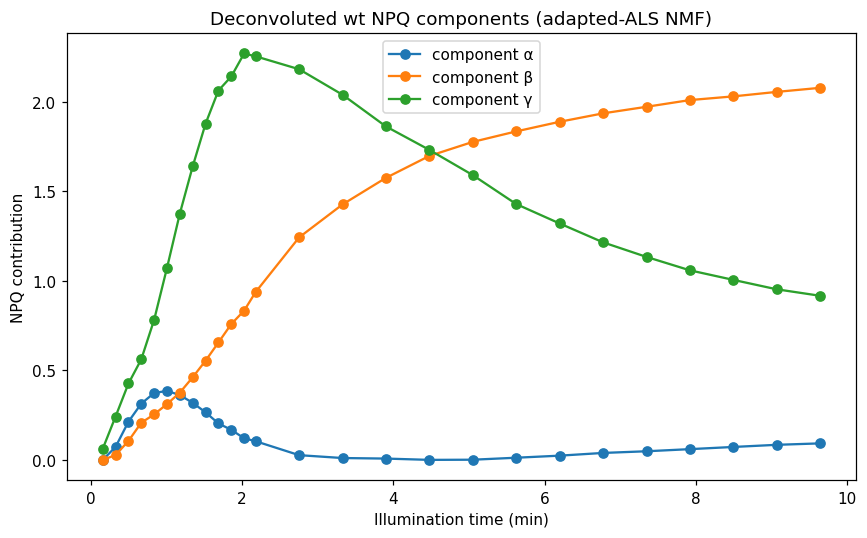

In [ ]:
order_by_lowlight = np.argsort(-W_wt[qp1_wt.argmin()])
labels = ['α', 'β', 'γ'][::1]
H_sorted = H_wt[order_by_lowlight]
W_sorted = W_wt[:, order_by_lowlight]
fig, ax = plt.subplots(figsize=(8, 5), dpi=110)
for k in range(3):
    ax.plot(t_min, H_sorted[k], 'o-', label=f'component {labels[k]}')
ax.set_xlabel('Illumination time (min)'); ax.set_ylabel('NPQ contribution')
ax.set_title('Deconvoluted wt NPQ components (adapted-ALS NMF)')
ax.legend(); plt.tight_layout(); plt.show()

**EN:** Fractional contributions of each component across the dataset, against (1-qP)ss — the
wt analogue of the paper's Fig. 3(b–d)/Fig. 4 contribution panels. Generated from the actual data.
**JP:** 各成分の寄与率を (1-qP)ss に対してプロットします（論文の寄与パネルに対応）。

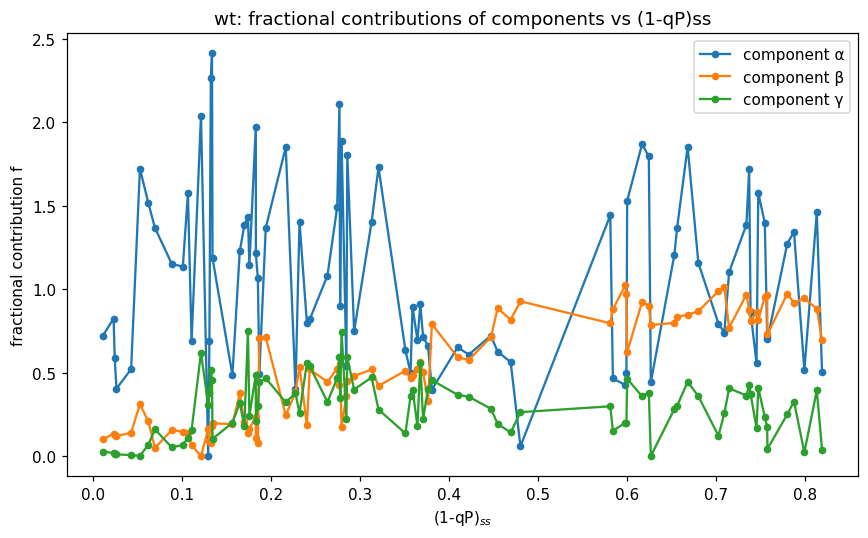

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5), dpi=110)
for k in range(3):
    ax.plot(qp1_wt, W_sorted[:, k], 'o-', ms=4, label=f'component {labels[k]}')
ax.set_xlabel('(1-qP)$_{ss}$'); ax.set_ylabel('fractional contribution f')
ax.set_title('wt: fractional contributions of components vs (1-qP)ss')
ax.legend(); plt.tight_layout(); plt.show()

## 10. Fit quality — adjusted r²

**EN:** For every curve we compute the adjusted r² of the NMF reconstruction
(1 − (1−R²)(m−1)/(m−p−1), m = 26 time points, p = 3 components) and compare it with the paper's
observation that pure PCA reconstructions degrade below (1-qP)ss ≈ 0.4 (Fig. 2e) while the full
pipeline should fit the data set accurately. Generated from the actual data.
**JP:** 各曲線のNMF再構成の自由度調整済み決定係数を計算し、(1-qP)ss に対してプロットします
（PCAのみの場合は低 (1-qP)ss で劣化するという論文の記述と比較）。

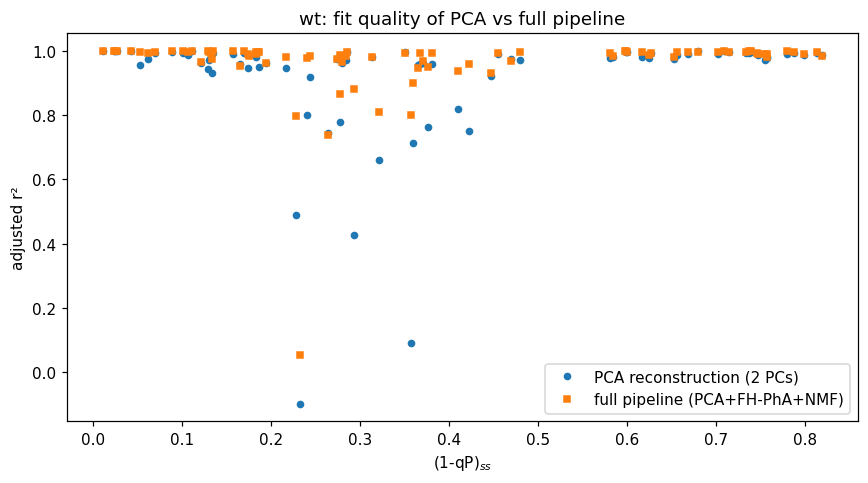

median adjusted r²: PCA 0.981 | full pipeline 0.993


In [ ]:
def adjusted_r2(Y, Yhat):
    m = Y.shape[1]
    ss_res = ((Y - Yhat)**2).sum(axis=1)
    ss_tot = ((Y - Y.mean(axis=0, keepdims=True))**2).sum(axis=1) + 1e-12
    r2 = 1 - ss_res/ss_tot
    p = 3
    return 1 - (1 - r2)*(m - 1)/(m - p - 1)

r2_nmf_wt = adjusted_r2(Y_wt, W_wt @ H_wt)
r2_pca_wt = adjusted_r2(Y_wt, mean_wt + scores_wt @ comps_wt)
fig, ax = plt.subplots(figsize=(8, 4.5), dpi=110)
ax.plot(qp1_wt, r2_pca_wt, 'o', ms=4, label='PCA reconstruction (2 PCs)')
ax.plot(qp1_wt, r2_nmf_wt, 's', ms=4, label='full pipeline (PCA+FH-PhA+NMF)')
ax.set_xlabel('(1-qP)$_{ss}$'); ax.set_ylabel('adjusted r²')
ax.set_title('wt: fit quality of PCA vs full pipeline')
ax.legend(); plt.tight_layout(); plt.show()
print('median adjusted r²: PCA %.3f | full pipeline %.3f' % (np.median(r2_pca_wt), np.median(r2_nmf_wt)))

## 11. The same pipeline applied to the npq1 dataset

**EN:** Re-run the identical pipeline on the npq1 (zeaxanthin-lacking) sheet: 37 curves. The paper
reports that in npq1 the slow α component is replaced by a slower, photoinhibition-like δ
component; we deconvolute with k = 3 and show the components and contributions as a demonstration
(this notebook does not attempt the paper's full four-component cross-genotype assignment).
**JP:** 同じパイプラインを npq1（ゼアキサンチン欠損）の37曲線に適用します。
論文では遅い成分 δ（光阻害様）への置き換えが報告されていますが、ここでは k=3 でのデモンストレーション
にとどめ、論文の4成分にわたる割り当ては扱いません。

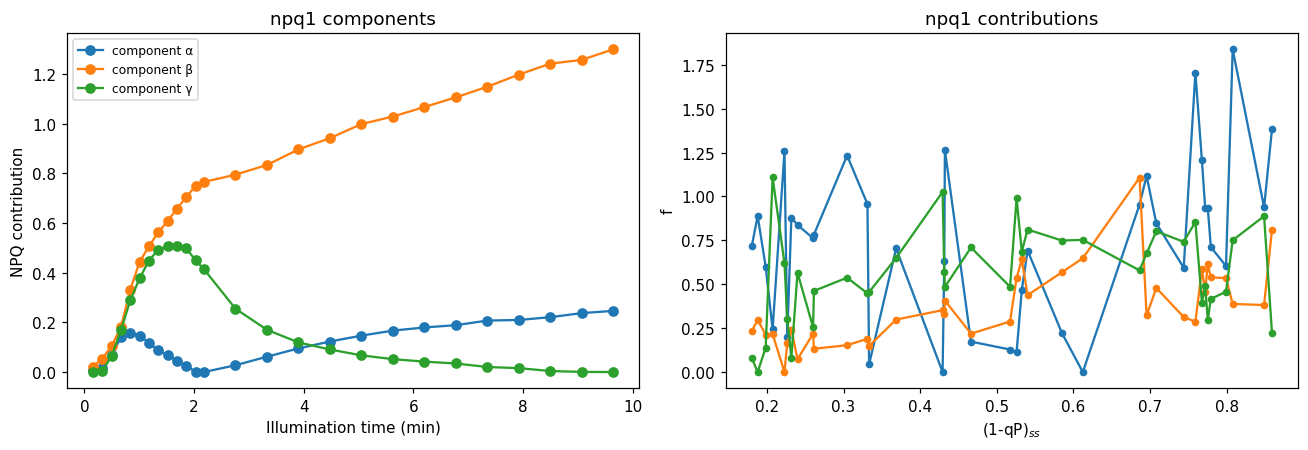

npq1 ALS iterations: 200, residual 0.6918


In [ ]:
P_npq1 = phasor_coords(Y_npq1, t_s)
_, comps_pha1, scores_pha1, _ = pca_curves(P_npq1)
Gp1, Sp1 = scores_pha1[:, 0], scores_pha1[:, 1]
V1, H0_1, f0_1 = identify_components(Y_npq1, Gp1, Sp1, qp1_npq1)
W_1, H_1, n_it_1, res_1 = nmf_als(Y_npq1, f0_1, H0_1)
o1 = np.argsort(-W_1[qp1_npq1.argmin()])
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), dpi=110)
for k in range(3):
    axes[0].plot(t_min, H_1[o1][k], 'o-', label=f'component {labels[k]}')
    axes[1].plot(qp1_npq1, W_1[:, o1][:, k], 'o-', ms=4, label=f'component {labels[k]}')
axes[0].set_xlabel('Illumination time (min)'); axes[0].set_ylabel('NPQ contribution')
axes[0].set_title('npq1 components'); axes[0].legend(fontsize=8)
axes[1].set_xlabel('(1-qP)$_{ss}$'); axes[1].set_ylabel('f'); axes[1].set_title('npq1 contributions')
plt.tight_layout(); plt.show()
print('npq1 ALS iterations: %d, residual %.4f' % (n_it_1, res_1))

## 12. Results export and comparison with published reference values

**EN:** Export the wt component curves and fractional contributions to CSV (downloadable from
Colab), and print a small comparison against the values stated in the paper. Note: the paper's
exact numeric NMF outputs are only in its figures, so these are plausibility checks, not a
quantitative equivalence claim.
**JP:** wtの成分曲線と寄与率をCSVへ書き出し、論文に記載された参照値（PC寄与率など）と比較します。
論文のNMFの数値は図の形式しかないため、これは妥当性確認であり定量的な等価性の主張ではありません。

In [ ]:
import pandas as pd
out = pd.DataFrame(np.column_stack([t_min, H_sorted.T]),
                   columns=['time_min', 'alpha', 'beta', 'gamma'])
out.to_csv('yggdrasill_wt_components.csv', index=False)
out_f = pd.DataFrame(np.column_stack([qp1_wt, W_sorted]),
                     columns=['(1-qP)ss', 'f_alpha', 'f_beta', 'f_gamma'])
out_f.to_csv('yggdrasill_wt_contributions.csv', index=False)
print('CSV written: yggdrasill_wt_components.csv, yggdrasill_wt_contributions.csv')
print()
print('reference (paper)              | this notebook')
print('PC1 variance 79.8%%             | %.1f%%' % (100*var_wt[0]))
print('PC2 variance 16.1%%             | %.1f%%' % (100*var_wt[1]))
print('number of wt components: 3     | %d' % H_wt.shape[0])
print('pipeline fits dataset accurately | median adj. r² %.3f' % np.median(r2_nmf_wt))

CSV written: yggdrasill_wt_components.csv, yggdrasill_wt_contributions.csv

reference (paper)              | this notebook
PC1 variance 79.8%             | 87.4%
PC2 variance 16.1%             | 11.1%
number of wt components: 3     | 3
pipeline fits dataset accurately | median adj. r² 0.993


## 13. Interpretation, limitations and references

**EN:** The pipeline deconvolutes the wt dataset into three components with distinct induction
kinetics and contributions that vary systematically with (1-qP)ss, and it applies unchanged to the
npq1 dataset — reproducing the paper's qualitative structure on the authors' own assembled data.

**Limitations.** (1) The author implementation is an opaque Windows binary; this is an AI-assisted
reimplementation from Notes S1 and Berry et al. (2007), validated only on plausibility checks
against values stated in the text (PC variance fractions; the exact NMF outputs exist only as paper
figures). (2) The low-light/high-light vertex choice and the third-vertex extrapolation follow the
paper's geometric description; the NMF ALS hyperparameters (iteration count, tolerance) are
implementation choices. (3) Chemical-treatment component assignment (DTT, nigericin, DCMU) and the
low-resolution pulse-sequence comparison are out of scope. (4) A single-dataset demonstration does
not verify the paper's biological conclusions.

**JP:** 本ノートブックは著者データセットを用いてwtデータを3成分へ分離し、npq1にも同じパイプラインを
適用しました。ただし著者の実装はWindowsバイナリのみのため、これはNotes S1とBerry et al. (2007) に
基づくAI支援の再実装であり、検証は論文本文の参照値との妥当性確認にとどまります。化学処理による成分の
帰属や低解像度パルス系列との比較は範囲外です。

**References.**
- Ramakers et al. 2024, New Phytologist 245(2):625–636, doi:10.1111/nph.20271 (CC BY 4.0).
- Notes S1 (equations and algorithms), Fig. S8 (vertex geometry), supplement of the same article.
- Berry M.W. et al. 2007, Comput. Stat. Data Anal. 52:155–173 (adapted ALS NMF).
- Data: L-Ramakers/Yggdrasill @ 89851ecab0ef8b25101da248c5ddfc14849ef7d4 (MIT-free? no license file; dataset per paper's Data availability).